# 1. SETUP & DATA PREPROCESSING

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

1. Load the original cleaned data

In [7]:
df = pd.read_csv('cleaned_data.csv')

2. Apply Feature Engineering (Encoding) determined during EDA

In [8]:
df_encoded = df.copy()

 Binary Encoding (0/1 Conversions)

In [9]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    if col in df_encoded.columns:
        if col == 'gender':
            df_encoded[col] = df_encoded[col].map({'Female': 1, 'Male': 0})
        else:
            df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

 Ordinal & One-Hot Encoding

In [10]:

if 'Contract' in df_encoded.columns:
    df_encoded['Contract'] = df_encoded['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

cols_to_get_dummies = ['PaymentMethod', 'InternetService']
existing_dummy_cols = [c for c in cols_to_get_dummies if c in df_encoded.columns]
df_encoded = pd.get_dummies(data=df_encoded, columns=existing_dummy_cols, drop_first=True)

print("Data successfully loaded and encoded for modeling!")
print(f"Ready dataset shape: {df_encoded.shape}")

Data successfully loaded and encoded for modeling!
Ready dataset shape: (7043, 23)


#  2. Train / Test Split
Before training our models, we need to split our dataset. We will use 80% of the data to train the algorithms and hold out 20% as an unseen test set to evaluate their real-world performance.

# 2. TRAIN / TEST SPLIT

In [11]:
from sklearn.model_selection import train_test_split

 Define Features (X) and Target (y)

In [12]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

Split the data (80% Train, 20% Test)

stratify=y ensures the same proportion of Churn yes/no in both sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Data successfully split!")
print(f"Training Set: {X_train.shape[0]} customers")
print(f"Testing Set: {X_test.shape[0]} customers")

Data successfully split!
Training Set: 5634 customers
Testing Set: 1409 customers


#3. Model 1: Decision Tree Classifier
A Decision Tree splits the data into branches based on feature questions (e.g., "Is contract month-to-month?"). It is highly interpretable. We restrict the depth of the tree (`max_depth=5`) to prevent overfitting.

# 3. DECISION TREE CLASSIFIER

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

1. Initialize the model

In [15]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

 2. Train the model

In [16]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

3. Make predictions on the unseen test set

In [17]:
dt_predictions = dt_model.predict(X_test)

 4. Evaluate the performance

In [18]:
print("--- DECISION TREE PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, dt_predictions) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, dt_predictions))

--- DECISION TREE PERFORMANCE ---
Accuracy Score: 79.91%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409



# 4. Model 2: Random Forest Classifier
Random Forest is an ensemble learning method that builds multiple decision trees (a "forest") and merges their predictions together to get a more accurate and stable result.

#  4. RANDOM FOREST CLASSIFIER

In [19]:
from sklearn.ensemble import RandomForestClassifier

1. Initialize the model (100 trees)

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)

2. Train the model

In [21]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, random_state=42)

 3. Make predictions on the unseen test set

In [22]:
rf_predictions = rf_model.predict(X_test)

 4. Evaluate the performance

In [23]:
print("--- RANDOM FOREST PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, rf_predictions) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, rf_predictions))

--- RANDOM FOREST PERFORMANCE ---
Accuracy Score: 80.34%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.68      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



<Axes: >

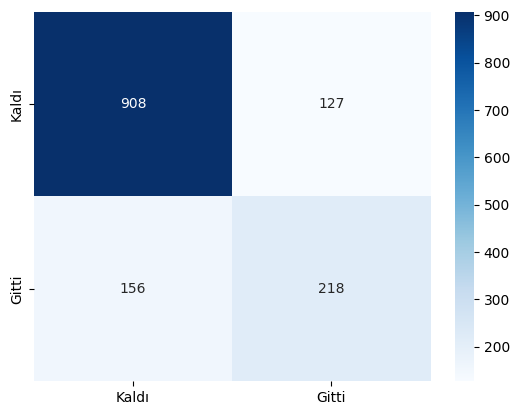

In [24]:

cm = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kaldı','Gitti'],
            yticklabels=['Kaldı','Gitti'])

<Axes: >

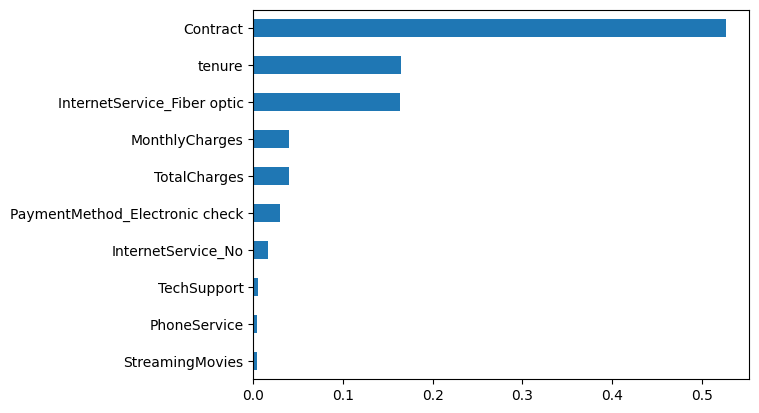

In [25]:
importances = pd.Series(dt_model.feature_importances_,
                         index=X_train.columns)
importances.sort_values().tail(10).plot(kind='barh')

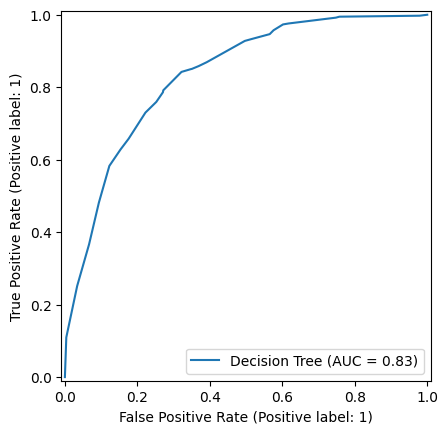

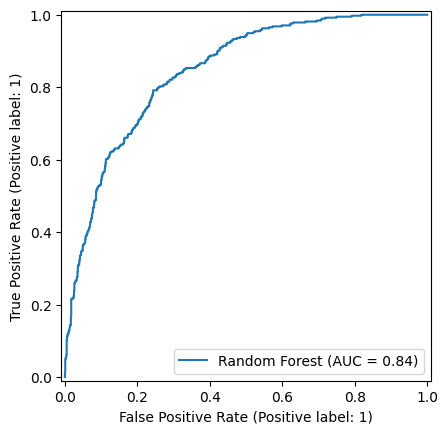

In [26]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
RocCurveDisplay.from_estimator(dt_model, X_test, y_test, name="Decision Tree")
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, name="Random Forest")

In [27]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib

print("--- requirements.txt İçin Kopyalanacak Kısım ---")
print(f"pandas=={pd.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"matplotlib=={matplotlib.__version__}")

--- requirements.txt İçin Kopyalanacak Kısım ---
pandas==2.2.2
scikit-learn==1.6.1
seaborn==0.13.2
matplotlib==3.10.0
